<a href="https://colab.research.google.com/github/emilioan55/TAREAS-MAESTRIA/blob/main/Actividad4EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 4**
Exploración de datos

---

*   NOMBRE: EMILIO ANDRES MENDOZA KAPLAN
*   MATRÍCULA: A00042485

En esta actividad trabajarás con el archivo `personal_loan.csv`, basado en un conjunto de datos sobre clientes bancarios y su comportamiento financiero disponible en Kaggle.

Los datos fueron recopilados para analizar la posibilidad de que los clientes acepten un préstamo personal y contienen información demográfica, financiera y de productos bancarios asociados. Los indicadores incluidos son:

* `ID`: Identificador único del cliente
* `Age`: Edad del cliente (años completos)
* `Experience`: Experiencia laboral en años
* `Income`: Ingreso anual del cliente (en miles de dólares. Por ejemplo, 60 = 60,000 USD/año)
* `ZIP Code`: Código postal del cliente
* `Family`: Número de miembros de la familia
* `CCAvg`: Promedio de gastos mensuales con tarjeta de crédito (en miles de dólares)
* `Education`: Nivel educativo (1 = graduado, 2 = universitario, 3 = posgrado)
* `Mortgage`: Monto de hipoteca que posee el cliente (en miles de dólares)
* `Securities Account`: Indicador de si tiene cuenta de valores (1 = sí, 0 = no)
* `CD Account`: Indicador de si tiene cuenta de certificado de depósito (1 = sí, 0 = no)
* `Online`: Indicador de si usa los servicios bancarios en línea (1 = sí, 0 = no)
* `CreditCard`: Indicador de si es titular de tarjeta de crédito (1 = sí, 0 = no)
* `Personal Loan`: Si el cliente aceptó (1) o no (0) un préstamo personal. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

1. Descarga el archivo: `personal_loan.csv` y guarda, en un dataframe (`loan_df`), todos sus registros.
* Haz que la columna `ID` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp /content/drive/MyDrive/Colab_Notebooks/Actividad_4EDA/personal_loan.csv .
# Cargar el archivo CSV en el dataframe 'loan_df', usando la columna 'ID' como índice
loan_df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Actividad_4EDA/personal_loan.csv', index_col='ID')

# Mostrar las primeras filas para verificar que se cargó correctamente
display(loan_df.head())

# Obtener el resumen de los tipos de datos
loan_df.info()

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
0,25,1,49,91108,4,1.6,1.0,0,0,Yes,No,0,0
1,45,19,34,90089,3,1.5,1.0,0,No,Yes,No,No,0
2,39,15,11,94720,1,1.0,1.0,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2.0,0,0,0,0,No,0
4,35,8,45,91330,4,1.0,2.0,0,0,No,No,0,1


<class 'pandas.core.frame.DataFrame'>
Index: 5037 entries, 0 to 5036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 5037 non-null   int64  
 1   Experience          5037 non-null   int64  
 2   Income              5037 non-null   int64  
 3   ZIP Code            5037 non-null   int64  
 4   Family              5037 non-null   int64  
 5   CCAvg               5037 non-null   float64
 6   Education           5037 non-null   float64
 7   Mortgage            5037 non-null   int64  
 8   Personal Loan       5037 non-null   object 
 9   Securities Account  5037 non-null   object 
 10  CD Account          5037 non-null   object 
 11  Online              5037 non-null   object 
 12  CreditCard          5037 non-null   object 
dtypes: float64(2), int64(6), object(5)
memory usage: 550.9+ KB


**Ocho columnas son numéricas y cinco son de texto**

2. Obtén las estadísticas descriptivas de las variables numéricas y examina cuidadosamente los valores obtenidos de cada columna.
* Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.
* Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.
* ¿Cuántos registros se eliminaron (considerando todas las acciones de este ejercicio) y qué porcentaje representa respecto al total del dataframe inicial?

2.1 Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.

In [4]:
# Seleccionar los nombres de las columnas numéricas del dataframe
columnas_numericas = loan_df.select_dtypes(include=[np.number]).columns

# Recorrer cada variable numérica individualmente
for col in columnas_numericas:
    # Extraer los valores de la columna a un arreglo de NumPy
    arr = loan_df[col].dropna().to_numpy()

    print(f"========================================")
    print(f" Variable: {col}")
    print(f"========================================")
    print(f"• Media:          {np.mean(arr):.2f}")
    print(f"• Mediana:        {np.median(arr):.2f}")
    print(f"• Mínimo:         {np.min(arr):.2f}")
    print(f"• Máximo:         {np.max(arr):.2f}")
    print(f"• Desv. Estándar: {np.std(arr):.2f}")
    print(f"• Percentil 25:   {np.percentile(arr, 25):.2f}")
    print(f"• Percentil 75:   {np.percentile(arr, 75):.2f}\n")


 Variable: Age
• Media:          45.41
• Mediana:        45.00
• Mínimo:         23.00
• Máximo:         144.00
• Desv. Estándar: 11.65
• Percentil 25:   35.00
• Percentil 75:   55.00

 Variable: Experience
• Media:          20.12
• Mediana:        20.00
• Mínimo:         -3.00
• Máximo:         43.00
• Desv. Estándar: 11.46
• Percentil 25:   10.00
• Percentil 75:   30.00

 Variable: Income
• Media:          73.90
• Mediana:        64.00
• Mínimo:         8.00
• Máximo:         224.00
• Desv. Estándar: 46.13
• Percentil 25:   39.00
• Percentil 75:   98.00

 Variable: ZIP Code
• Media:          93152.87
• Mediana:        93437.00
• Mínimo:         9307.00
• Máximo:         96651.00
• Desv. Estándar: 2119.43
• Percentil 25:   91911.00
• Percentil 75:   94608.00

 Variable: Family
• Media:          2.39
• Mediana:        2.00
• Mínimo:         -3.00
• Máximo:         4.00
• Desv. Estándar: 1.15
• Percentil 25:   1.00
• Percentil 75:   3.00

 Variable: CCAvg
• Media:          1.94
• Median

Filtra el dataframe para visualizar los registros en que la edad supera los 100 años y elimínalos si no son pausibles.

Primero encuentro los valores mayores de 100 años para decidir si se borran los registros

In [5]:
# Extraer la columna 'Age' como arreglo de NumPy y crear la máscara
edades = loan_df['Age'].to_numpy()
mascara_mayores_100 = edades > 100

total_sospechosos = np.sum(mascara_mayores_100)
print(f"Total de registros con edad superior a 100 años: {total_sospechosos}")

if total_sospechosos > 0:
    print("\n--- Inspección de registros sospechosos ---")
    display(loan_df[mascara_mayores_100])
else:
    print("\nNo se encontraron registros con edades superiores a 100 años.")

Total de registros con edad superior a 100 años: 3

--- Inspección de registros sospechosos ---


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
10,123,39,105,94710,4,2.4,3.0,0,0,0,0,No,0
250,144,6,29,94305,3,1.0,2.0,117,0,No,0,No,No
4800,130,7,73,94028,1,2.5,1.0,135,0,No,0,0,0


**A mi juicio, son valores que deben borrarse por que son inviables (123, 130 y 144 años)**

In [6]:
#Borra los registros mayores a 100 años
loan_df = loan_df[loan_df['Age'] <= 100]

print(f"Registros eliminados. Total de filas restantes en el DataFrame: {len(loan_df)}")

Registros eliminados. Total de filas restantes en el DataFrame: 5034


**Se borraron los tres registros mayores a cien años**

2.2 Analiza el resto de las variables y elimina aquellos registros que contengan valores inválidos o inconsistentes. Para cada acción que realices, justifica la decisión, explicando por qué consideras que el valor es incorrecto.

**ANALIZO PRIMERO LA COLUMNA EXPERIENCIA, PUES EN LOS ESTADÍSTICOS APARECE UN MÍNMO NEGATIVO. SOLO CONSERVO VALORES DE EXPERIENCIA MAYOR O IGUAL A CERO**

In [7]:
# 1. Guardar el número total de filas antes de la limpieza
filas_antes = len(loan_df)

# 2. Extraer la columna 'Experience' como arreglo de NumPy y aplicar la condición (>= 0)
experiencia = loan_df['Experience'].to_numpy()
mascara_validos = experiencia >= 0

# 3. Filtrar automáticamente el DataFrame para conservar solo los registros válidos
loan_df = loan_df[mascara_validos]

# 4. Calcular el número de valores/registros desechados y los válidos restantes
filas_eliminadas = filas_antes - len(loan_df)
filas_restantes = len(loan_df)

print("=== Reporte de limpieza de Experience ===")
print(f"• Registros desechados (con experiencia negativa): {filas_eliminadas}")
print(f"• Registros válidos restantes en el DataFrame: {filas_restantes}")

=== Reporte de limpieza de Experience ===
• Registros desechados (con experiencia negativa): 53
• Registros válidos restantes en el DataFrame: 4981


**HAGO LO MISMO CON LA COLUMNA FAMILIA, QUE APARECE CON NÚMEROS NEGATIVOS EN EL ANALISIS ESTADÍSTICO**


In [8]:
# 1. Guardar el número total de filas antes de la limpieza
filas_antes = len(loan_df)

# 2. Extraer la columna 'Family' como arreglo de NumPy y aplicar la condición (>= 0)
familia = loan_df['Family'].to_numpy()
mascara_validos = familia >= 0

# 3. Filtrar automáticamente el DataFrame para conservar solo los registros válidos
loan_df = loan_df[mascara_validos]

# 4. Calcular el número de valores/registros desechados y los válidos restantes
filas_eliminadas = filas_antes - len(loan_df)
filas_restantes = len(loan_df)

print("=== Reporte de limpieza de Family ===")
print(f"• Registros desechados (con valores menores a 0): {filas_eliminadas}")
print(f"• Registros válidos restantes en el DataFrame: {filas_restantes}")

=== Reporte de limpieza de Family ===
• Registros desechados (con valores menores a 0): 2
• Registros válidos restantes en el DataFrame: 4979


**PARA EL CAMPO EDUCACION, PRIMERO CAMBIARÉ EL TIPO DE DATO A TEXTO PUES ES ORDINAL (1, 2 o 3, de acuerdo con la descricpión de los datos).**

In [9]:
# Guardar el número total de filas antes de la limpieza

filas_antes = len(loan_df)

#Cambiar el tipo de dato de la columna 'Education' a texto (string)
# Esto asegura que los valores se traten como categorías de texto exactas
loan_df['Education'] = loan_df['Education'].astype(str)

#Extraer la columna como arreglo de NumPy
educacion = loan_df['Education'].to_numpy()

#Crear la máscara para conservar únicamente los valores '1', '2' o '3'
# Usamos un conjunto de valores permitidos y evaluamos con NumPy/in
valores_permitidos = {'1.0', '2.0', '3.0', '1', '2', '3'} # Incluimos por si quedaron con formato decimal previo (.0)
mascara_validos = np.isin(educacion, list(valores_permitidos))

#Filtrar el DataFrame de manera automática
loan_df = loan_df[mascara_validos]

#Calcular métricas de limpieza
filas_eliminadas = filas_antes - len(loan_df)
filas_restantes = len(loan_df)

print("=== Reporte de limpieza de Education ===")
print(f"• Registros desechados (valores diferentes a 1, 2 o 3): {filas_eliminadas}")
print(f"• Registros válidos restantes en el DataFrame: {filas_restantes}")

# (Opcional) Mostrar los valores únicos actuales en la columna para verificar
print(f"• Valores únicos limpios en Education: {loan_df['Education'].unique()}")

=== Reporte de limpieza de Education ===
• Registros desechados (valores diferentes a 1, 2 o 3): 1
• Registros válidos restantes en el DataFrame: 4978
• Valores únicos limpios en Education: ['1.0' '2.0' '3.0']


**El campo Zip_Code no tengo elementos para buscar eliminarlos pues se encuentran dentro del rango de valores que tienen en Estados Unidos. Un búsqueda para depurarlos requeriría tener el catálogo de codigos postales y mayor informacipon de los clientes para busacr que correspondiera el ZipCode con los datos de la dirección del clente.**

**En total quedaron 4978 registros hasta este punto de 5037. Por lo tanto, se borraron 59 registros, el 1.17 porciento de los registros originales.**

3. Obtén las estadísticas descriptivas de las variables de texto e imprime las frecuencias de sus categorías.
* Algunas columnas almacenan valores binarios utilizando distintos formatos. Unifica estos valores de manera consistente, asegurándote de que coincidan con la descripción de las variables al inicio de esta libreta.

In [10]:
# Lista de tus variables de texto / binarias
variables_texto = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']

print("=== PASO 1: UNIFICACIÓN CONSISTENTE DE FORMATOS ===")
for col in variables_texto:
    # Convertir a string, quitar espacios y pasar a minúsculas para estandarizar de forma segura
    loan_df[col] = loan_df[col].astype(str).str.strip().str.lower()

    # Mapear variaciones comunes (como 'yes', 'true', '1.0', etc.) a '1' y '0'
    mapeo = {
        'yes': '1', 'true': '1', '1.0': '1', '1': '1', 'sí': '1', 'si': '1',
        'no': '0', 'false': '0', '0.0': '0', '0': '0'
    }

    loan_df[col] = loan_df[col].map(mapeo).fillna(loan_df[col])

print("¡Valores unificados correctamente a '1' y '0' según la descripción!\n")


# Lista de tus variables de texto / binarias
variables_texto = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']

# Recorrer cada variable de texto de manera individual
for col in variables_texto:
    print(f"========================================")
    print(f" Variable: {col}")
    print(f"========================================")

    # Obtener el resumen descriptivo básico de la columna (conteo, valor más frecuente, etc.)
    resumen = loan_df[col].describe()
    print(f"• Total de registros válidos (Count): {resumen['count']}")
    print(f"• Categoría más frecuente (Top):       {resumen['top']}")
    print(f"• Frecuencia del valor más alto (Freq): {resumen['freq']}")

    print("\n• Frecuencias detalladas de sus categorías:")
    frecuencias = loan_df[col].value_counts(dropna=False)
    for categoria, conteo in frecuencias.items():
        porcentaje = (conteo / len(loan_df)) * 100
        print(f"    - Categoría '{categoria}': {conteo} registros ({porcentaje:.2f}%)")

    print("\n")

=== PASO 1: UNIFICACIÓN CONSISTENTE DE FORMATOS ===
¡Valores unificados correctamente a '1' y '0' según la descripción!

 Variable: Personal Loan
• Total de registros válidos (Count): 4978
• Categoría más frecuente (Top):       0
• Frecuencia del valor más alto (Freq): 4493

• Frecuencias detalladas de sus categorías:
    - Categoría '0': 4493 registros (90.26%)
    - Categoría '1': 485 registros (9.74%)


 Variable: Securities Account
• Total de registros válidos (Count): 4978
• Categoría más frecuente (Top):       0
• Frecuencia del valor más alto (Freq): 4459

• Frecuencias detalladas de sus categorías:
    - Categoría '0': 4459 registros (89.57%)
    - Categoría '1': 519 registros (10.43%)


 Variable: CD Account
• Total de registros válidos (Count): 4978
• Categoría más frecuente (Top):       0
• Frecuencia del valor más alto (Freq): 4675

• Frecuencias detalladas de sus categorías:
    - Categoría '0': 4675 registros (93.91%)
    - Categoría '1': 303 registros (6.09%)


 Variable

4. Verifica si hay registros duplicados y si fuera así, elimínalos del dataframe.
* Asegúrate de reiniciar el índice para mantener una secuencia continua tras todas las eliminaciones de registros que hasta este punto se han realizado.

In [11]:
# Reinicializar el índice del DataFrame
# drop=True evita que el índice anterior se convierta en una columna adicional
loan_df = loan_df.reset_index(drop=True)

print("¡Índice reinicializado correctamente!")
print(f"Nuevo rango del índice: de {loan_df.index.min()} a {loan_df.index.max()}\n")

# 2. Buscar y contar registros duplicados
# duplicated() detecta filas completas repetidas
duplicados = loan_df[loan_df.duplicated()]
total_duplicados = len(duplicados)

print(f"=== ANÁLISIS DE DUPLICADOS ===")
print(f"• Total de registros duplicados encontrados: {total_duplicados}")

if total_duplicados > 0:
    print("\nMostrando los registros duplicados:")
    display(duplicados)

    # Ahora los eliminamos
    loan_df = loan_df.drop_duplicates().reset_index(drop=True)
    print(f"Registros después de eliminar duplicados: {len(loan_df)}")
else:
    print("\n¡Excelente! El DataFrame no contiene registros duplicados.")

¡Índice reinicializado correctamente!
Nuevo rango del índice: de 0 a 4977

=== ANÁLISIS DE DUPLICADOS ===
• Total de registros duplicados encontrados: 36

Mostrando los registros duplicados:


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4942,47,21,42,95841,4,0.1,1.0,0,0,0,0,1,1
4943,64,40,169,91320,2,2.1,1.0,122,0,0,0,1,0
4944,44,18,68,93943,4,2.9,1.0,0,0,1,0,0,0
4945,63,39,49,90275,1,0.8,1.0,103,0,0,0,1,0
4946,35,11,24,95521,4,0.4,2.0,0,0,0,0,0,0
4947,53,28,14,94005,4,0.8,1.0,0,0,0,0,1,1
4948,37,13,79,91330,1,3.6,2.0,104,0,0,0,1,0
4949,45,21,91,95054,1,4.7,1.0,0,0,0,0,1,0
4950,51,25,175,90089,3,0.7,1.0,312,1,0,0,0,0
4951,43,18,204,91902,2,8.8,1.0,0,0,0,0,1,0


Registros después de eliminar duplicados: 4942


**SE ELIMINARON 36 REGISTROS DUPLICADOS**

Vuelvo a reiniciar el indice

In [12]:
loan_df = loan_df.reset_index(drop=True)

print("¡Índice reinicializado correctamente!")

¡Índice reinicializado correctamente!


5. Aunque hasta ahora se han considerado los tipos de datos inferidos por pandas, antes del EDA es recomendable revisar la naturaleza estadística de cada variable (continua, discreta, categórica, binaria, etc.) para aplicar el análisis adecuado.

* Efectúa las siguientes conversiones:
  - Nominal: ZIP Code - `object`
  - Ordinal: Education - `category` con orden 1, 2, 3
  - Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard - `category`
* Crea dos listas llamadas `num_cols` y `cat_cols` que contengan los nombres de las variables numéricas (int64, float64) y categóricas (object, category) del dataset, respectivamente.

In [13]:
from pandas.api.types import CategoricalDtype

print("=== CONVERSIÓN DE TIPOS DE DATOS ===")

# 1. Nominal: ZIP Code a tipo object (texto/categórico nominal)
loan_df['ZIP Code'] = loan_df['ZIP Code'].astype(str)
print("• ZIP Code convertido a: object (Nominal)")

# 2. Ordinal: Education a tipo category con enteros seguros (manejando decimales/nulos si los hay)
loan_df['Education'] = pd.to_numeric(loan_df['Education'], errors='coerce').astype('Int64')
educacion_orden = CategoricalDtype(categories=[1, 2, 3], ordered=True)
loan_df['Education'] = loan_df['Education'].astype(educacion_orden)
print("• Education convertida a: category ordenada (Ordinal: 1, 2, 3)")

# 3. Binarias: Personal Loan, Securities Account, CD Account, Online, CreditCard a category
variables_binarias = ['Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
for col in variables_binarias:
    loan_df[col] = loan_df[col].astype('category')

print(f"• Variables binarias convertidas a category: {', '.join(variables_binarias)}")

print("\n=== VERIFICACIÓN DE TIPOS DE DATOS ACTUALIZADOS ===")
display(loan_df.dtypes)

=== CONVERSIÓN DE TIPOS DE DATOS ===
• ZIP Code convertido a: object (Nominal)
• Education convertida a: category ordenada (Ordinal: 1, 2, 3)
• Variables binarias convertidas a category: Personal Loan, Securities Account, CD Account, Online, CreditCard

=== VERIFICACIÓN DE TIPOS DE DATOS ACTUALIZADOS ===


,0
Age,int64
Experience,int64
Income,int64
ZIP Code,object
Family,int64
CCAvg,float64
Education,category
Mortgage,int64
Personal Loan,category
Securities Account,category


In [14]:
# 1. Crear la lista de variables numéricas (incluyendo enteros y flotantes)
num_cols = loan_df.select_dtypes(include=['int64', 'float64', np.number]).columns.tolist()

# 2. Crear la lista de variables categóricas (incluyendo object y category)
cat_cols = loan_df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"num_cols ({len(num_cols)} variables):")
print(num_cols)

print(f"\ncat_cols ({len(cat_cols)} variables):")
print(cat_cols)

num_cols (6 variables):
['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage']

cat_cols (7 variables):
['ZIP Code', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


# Análisis exploratorio de datos (univariado)

6. Para el análisis de las variables numéricas obtén nuevamente las estadísticas descriptivas incluyendo los valores de simetría y curtosis.
* Clasifica las variables `Age`, `Income` y `Mortgage` según los valores observados de asimetría y curtosis.

In [15]:
# Asegurarnos de usar la lista 'num_cols' que creamos anteriormente
# Si prefieres calcularlo directo, también puedes usar loan_df[num_cols]

print("=== ESTADÍSTICAS DESCRIPTIVAS AMPLIADAS (Simetría y Curtosis) ===\n")

# Crear un DataFrame resumen para organizar los cálculos por cada variable numérica
resumen_numerico = pd.DataFrame(index=num_cols)

resumen_numerico['Media'] = loan_df[num_cols].mean()
resumen_numerico['Mediana'] = loan_df[num_cols].median()
resumen_numerico['Desv. Estándar'] = loan_df[num_cols].std()
resumen_numerico['Mínimo'] = loan_df[num_cols].min()
resumen_numerico['Máximo'] = loan_df[num_cols].max()

# Cálculo de simetría (skew) y curtosis utilizando los métodos integrados de Pandas
resumen_numerico['Simetría (Skewness)'] = loan_df[num_cols].skew()
resumen_numerico['Curtosis (Kurtosis)'] = loan_df[num_cols].kurtosis()

# Mostrar la tabla completa redondeada a 2 decimales para mayor legibilidad
display(resumen_numerico.round(2))

=== ESTADÍSTICAS DESCRIPTIVAS AMPLIADAS (Simetría y Curtosis) ===



,Media,Mediana,Desv. Estándar,Mínimo,Máximo,Simetría (Skewness),Curtosis (Kurtosis)
Age,45.56,46.0,11.31,24.0,67.0,-0.02,-1.16
Experience,20.34,20.0,11.31,0.0,43.0,-0.02,-1.13
Income,73.82,64.0,46.11,8.0,224.0,0.84,-0.05
Family,2.39,2.0,1.15,1.0,4.0,0.16,-1.40
CCAvg,1.94,1.5,1.75,0.0,10.0,1.59,2.64
Mortgage,56.65,0.0,101.87,0.0,635.0,2.10,4.76


Clasifica las variables Age, Income y Mortgage según los valores observados de asimetría y curtosis.

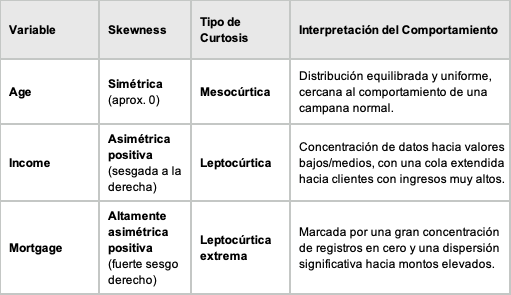

7. Genera un histograma para cada variable numérica, incluyendo la curva KDE y la curva de una distribución normal como referencia.
* Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.
* Para cada variable, crea un gráfico de boxplot individual que incluya la media.
* Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?

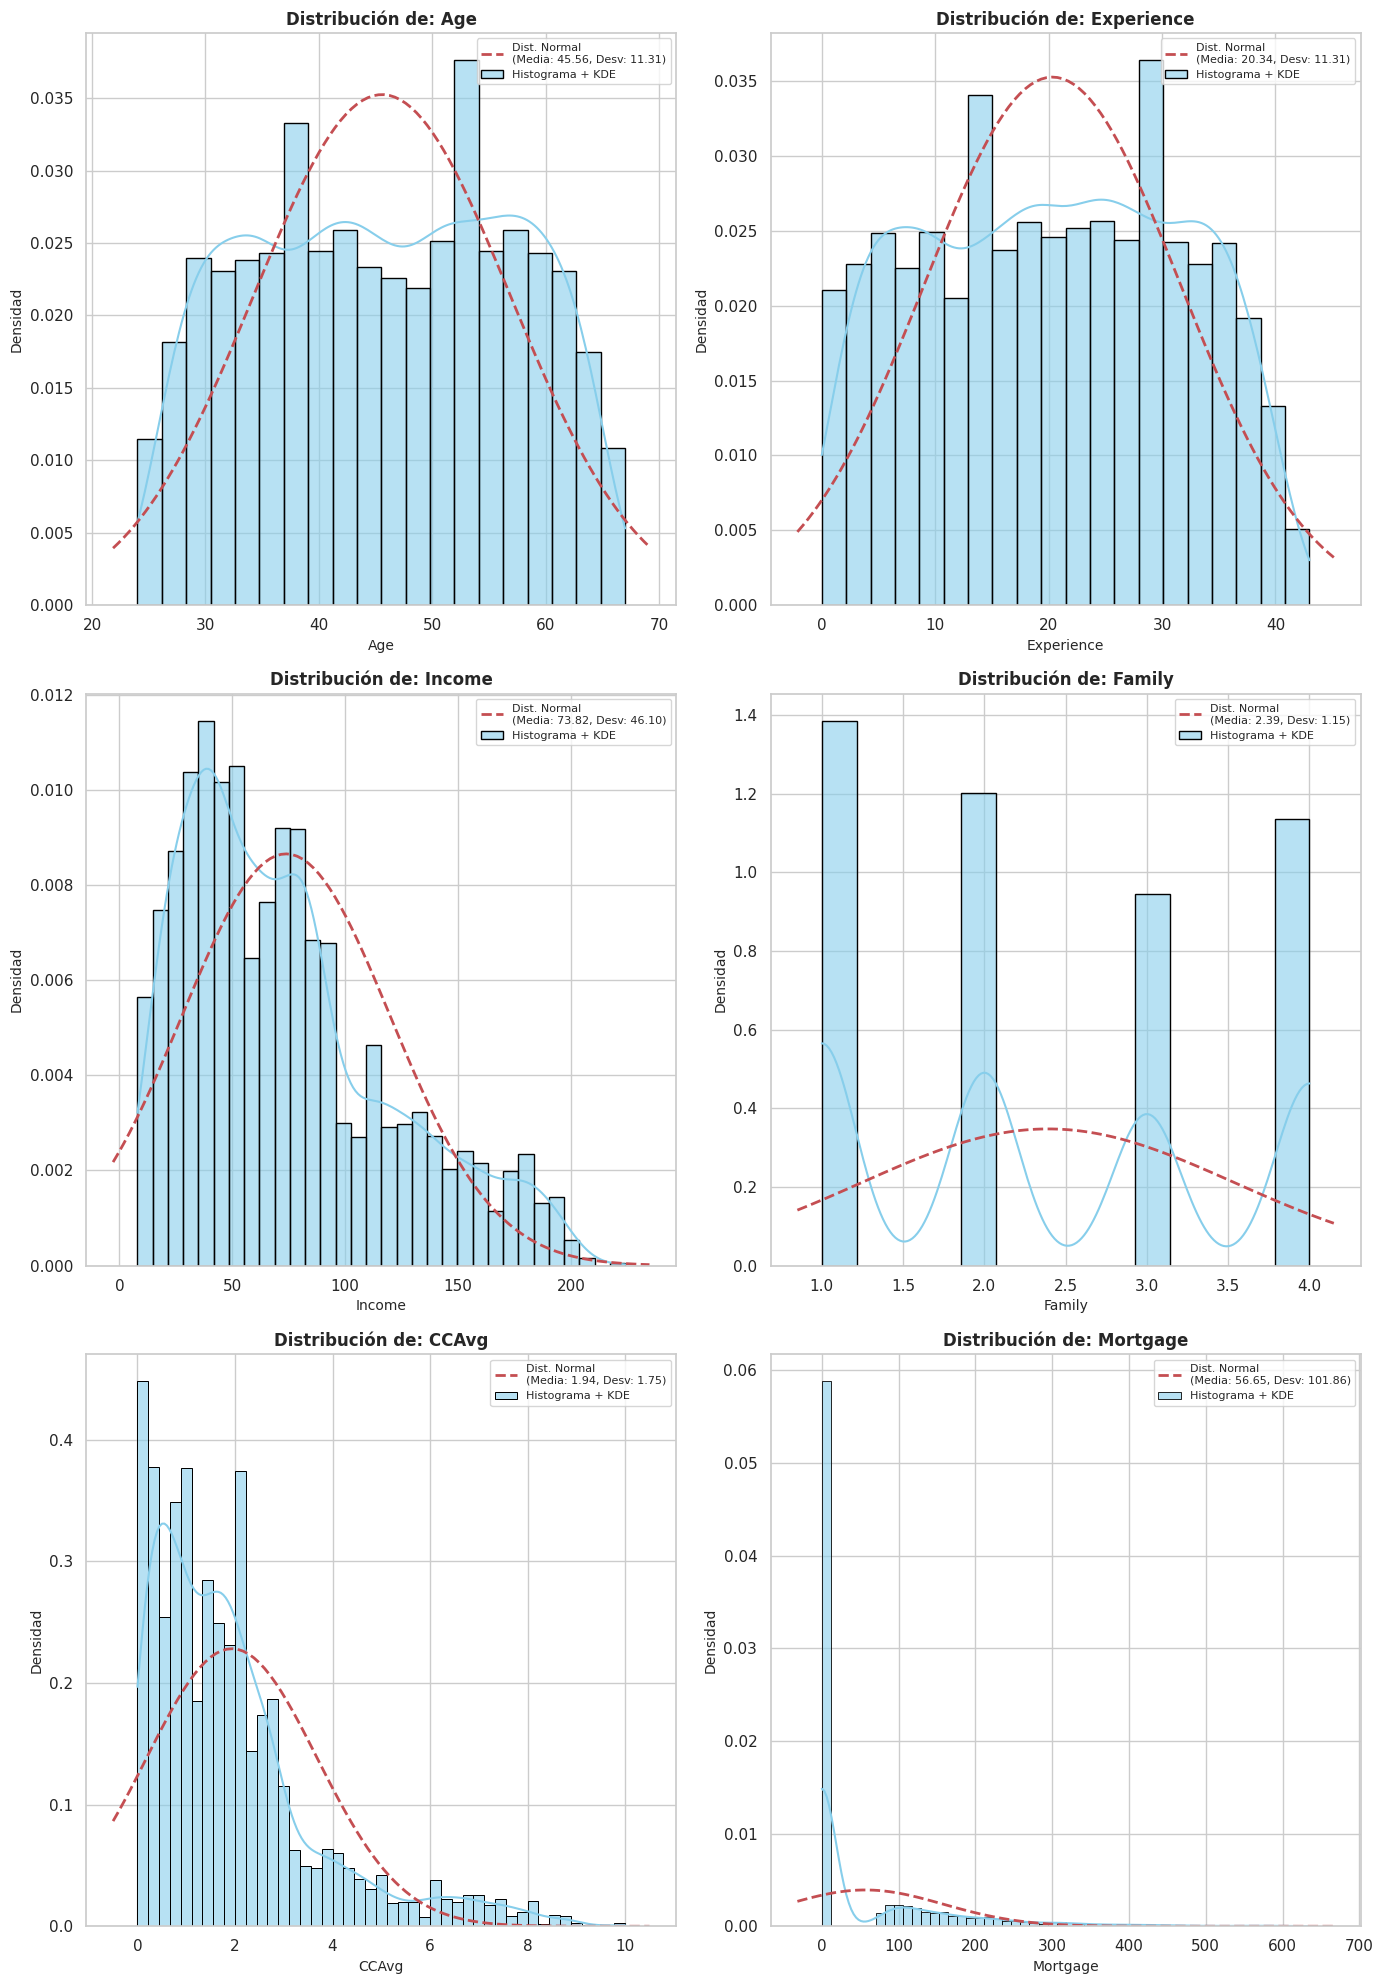

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# Crear una cuadrícula de subplots (ajustada para 8 variables numéricas en 4 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 20))
axes = axes.flatten()

# Recorrer cada variable numérica para generar su gráfico
for i, col in enumerate(num_cols):
    ax = axes[i]
    data = loan_df[col].dropna()

    # 1. Histograma con la curva KDE estimada por los datos
    sns.histplot(
        data,
        kde=True,
        stat="density",
        ax=ax,
        color="skyblue",
        edgecolor="black",
        alpha=0.6,
        label="Histograma + KDE"
    )

    # 2. Calcular la media (mu) y desviación estándar (std) para ajustar la distribución normal teórica
    mu, std = norm.fit(data)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    # 3. Graficar la curva normal de referencia (sin caracteres especiales que causen warnings)
    etiqueta_normal = f"Dist. Normal\n(Media: {mu:.2f}, Desv: {std:.2f})"
    ax.plot(
        x,
        p,
        'r--',
        linewidth=2,
        label=etiqueta_normal
    )

    # Títulos y etiquetas estéticas
    ax.set_title(f'Distribución de: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Densidad', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)

# Ajustar el diseño de la cuadrícula para evitar solapamientos
plt.tight_layout()
plt.show()

7.1 Para las variables que clasificaste antes, compara los histogramas generados con los valores numéricos calculados y comenta si la forma de cada distribución coincide con lo esperado.

**Los histogramas generados coinciden sensiblemente con los valores numéricos calculados y la forma de cada distribución coincide con lo esperado**

7.2 Para cada variable, crea un gráfico de boxplot individual que incluya la media.

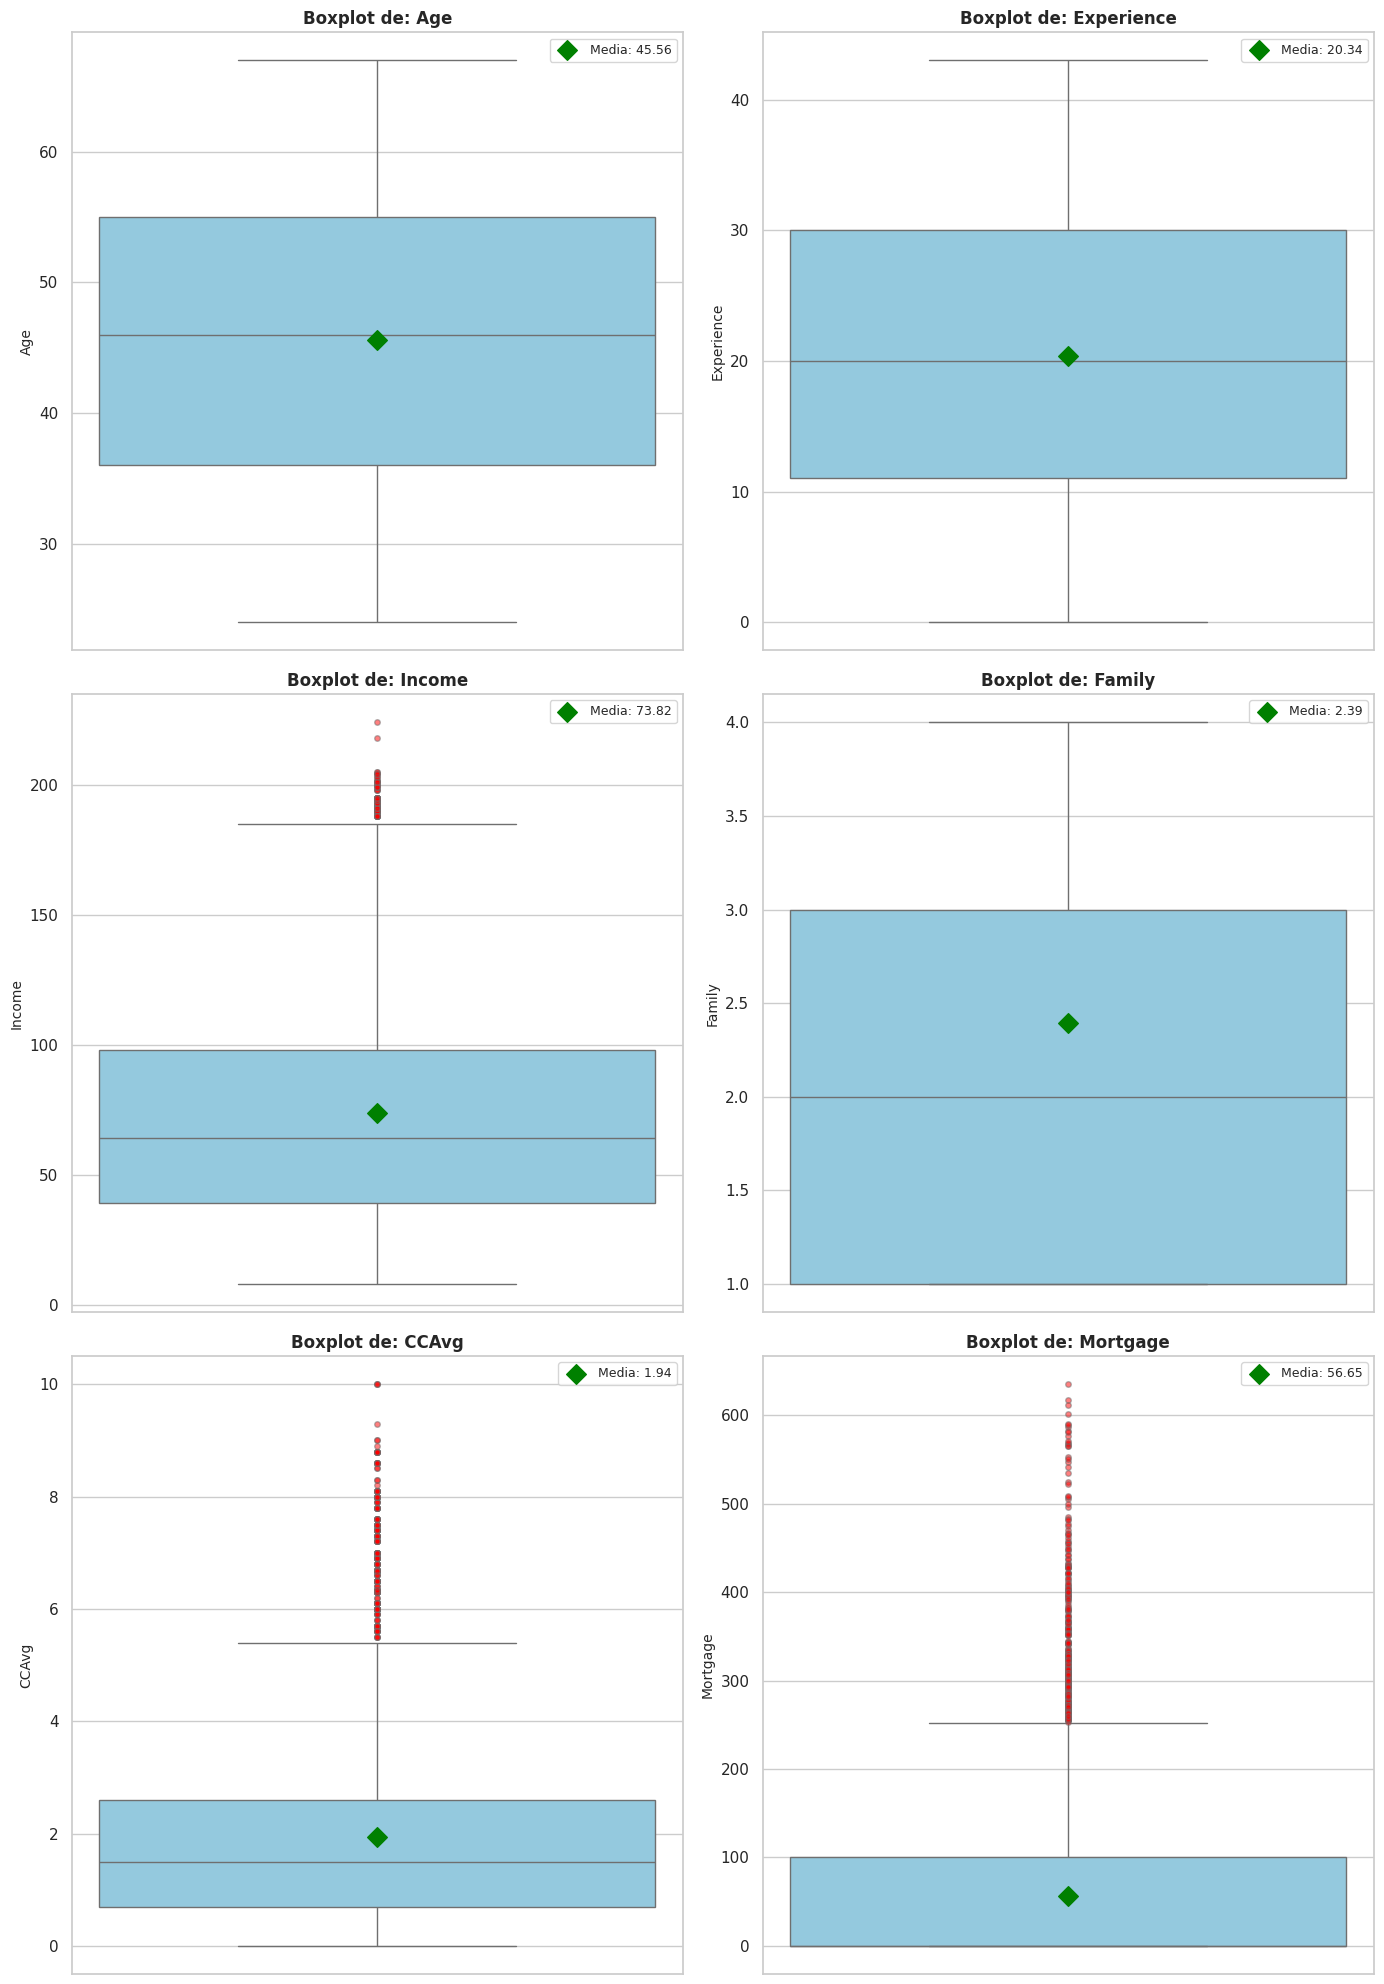

In [17]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# Crear una cuadrícula de subplots para las 6 variables numéricas (3 filas x 2 columnas)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 20))
axes = axes.flatten()

# Recorrer cada variable numérica para generar su boxplot
for i, col in enumerate(num_cols):
    ax = axes[i]
    data = loan_df[col].dropna()

    # 1. Generar el boxplot
    sns.boxplot(
        y=data,
        ax=ax,
        color="skyblue",
        flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 4, "alpha": 0.5}
    )

    # 2. Calcular y marcar la media aritmética en el boxplot con un símbolo distintivo (diamante verde)
    media_val = data.mean()
    ax.scatter(
        [0], [media_val],
        color="green",
        s=100,
        marker="D",
        zorder=5,
        label=f"Media: {media_val:.2f}"
    )

    # Títulos y etiquetas
    ax.set_title(f'Boxplot de: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col, fontsize=10)
    ax.legend(loc='upper right', fontsize=9)

# Ajustar diseño para evitar solapamientos
plt.tight_layout()
plt.show()

7.3 Analiza la posición de la media respecto a la mediana. ¿Qué indica esta relación sobre el sesgo (asimetría) de la distribución?

**Indica el sentido del sesgo, en este caso en las gráficas verticales, cuando la media se encuentra por encima de la mediana, el sesgo es positivo, cuando se encuentra por debajo es negativo y cuando coincide es simétrica.**

****

8. Obtén las estadísticas descriptivas de las variables categóricas.
* Genera un gráfico de barras para cada variable. En las de alta cardinalidad, sólo incluye los 10 valores más relevantes.

=== ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES CATEGÓRICAS ===



,Education,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,4942,4942,4942,4942,4942,4942
unique,3,2,2,2,2,2
top,1,0,0,0,1,0
freq,2079,4463,4427,4641,2952,3489



=== GENERACIÓN DE GRÁFICOS DE BARRAS ===


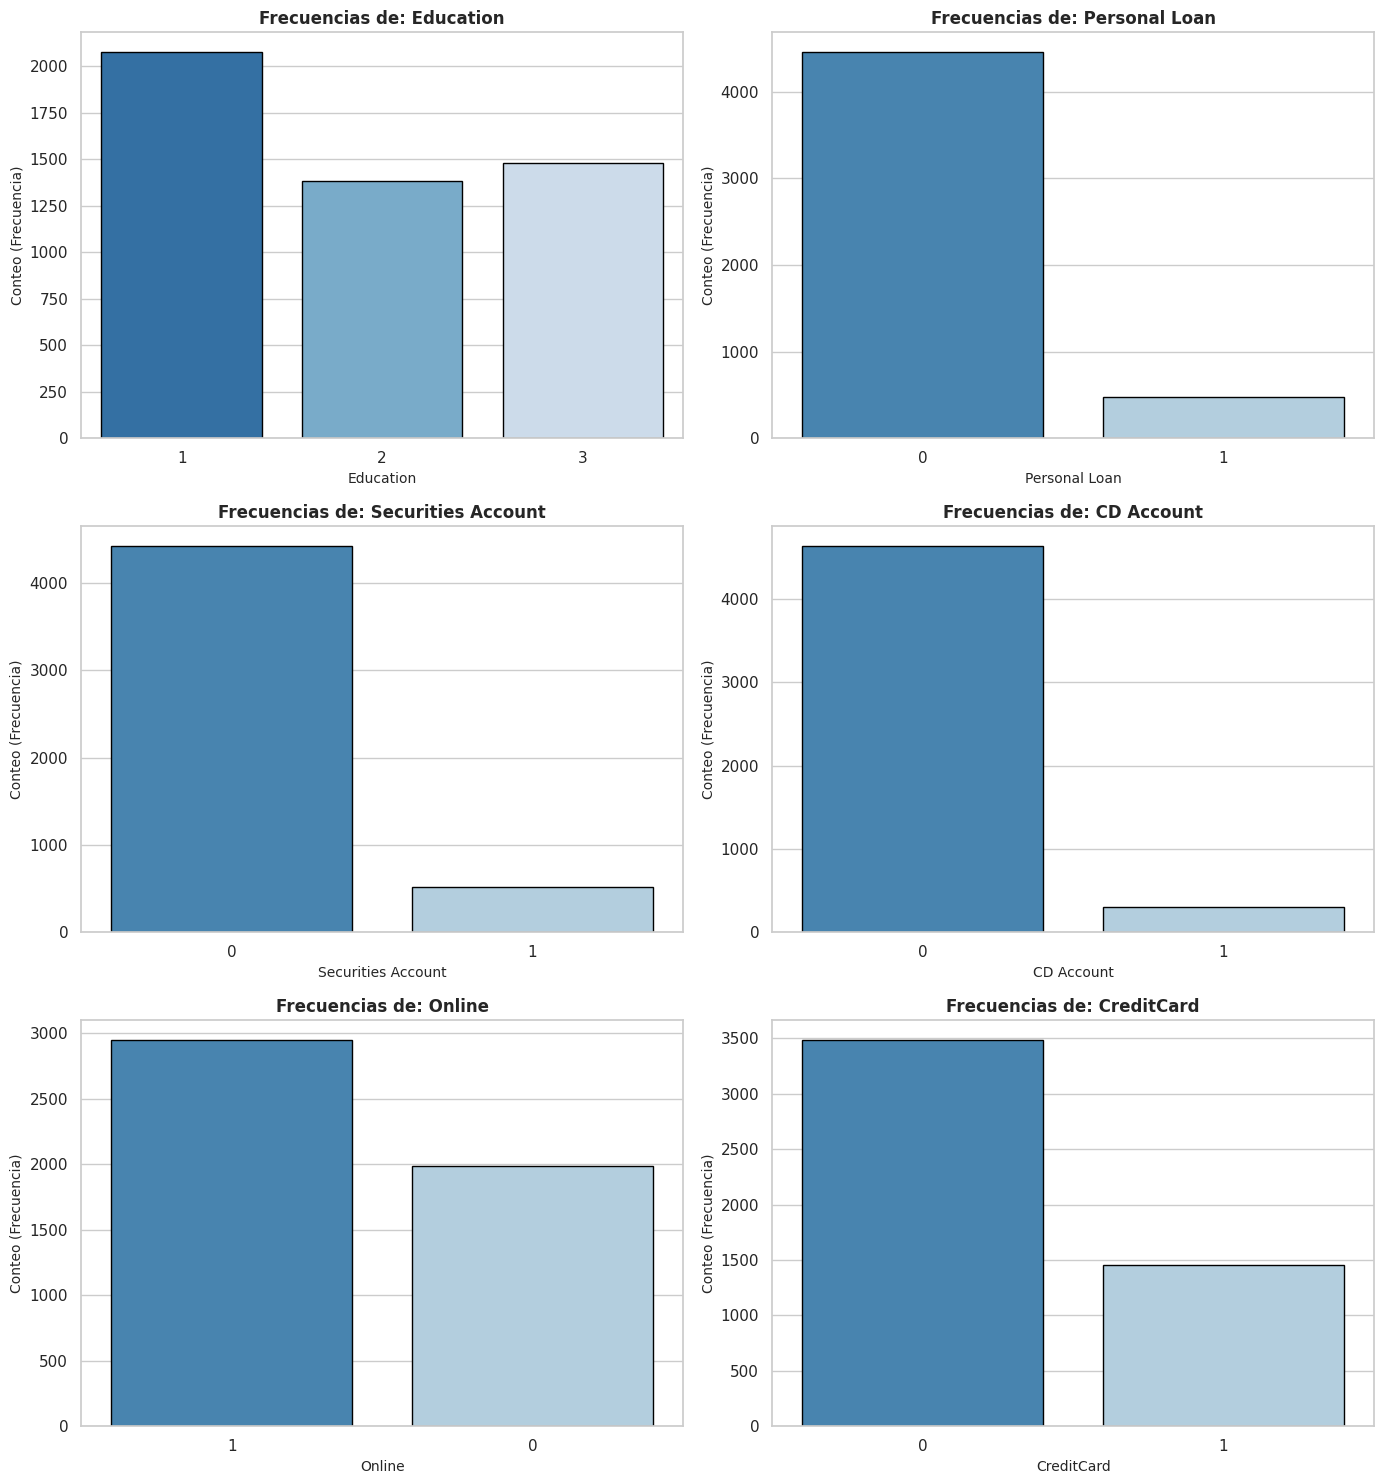

In [18]:
# Definir la lista de variables categóricas incluyendo Education (y excluyendo ZIP Code)
cat_cols = ['Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']

sns.set_theme(style="whitegrid")

print("=== ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES CATEGÓRICAS ===\n")
display(loan_df[cat_cols].describe())

print("\n=== GENERACIÓN DE GRÁFICOS DE BARRAS ===")
# 6 variables en una cuadrícula de 3 filas x 2 columnas
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    # Usamos sort_index() en Education para que las barras queden ordenadas del 1 al 3
    if col == 'Education':
        frecuencias = loan_df[col].value_counts(dropna=False).sort_index()
    else:
        frecuencias = loan_df[col].value_counts(dropna=False)

    # Gráfico de barras optimizado sin advertencias de Seaborn
    sns.barplot(
        x=frecuencias.index.astype(str),
        y=frecuencias.values,
        hue=frecuencias.index.astype(str),
        palette="Blues_r",
        legend=False,
        ax=ax,
        edgecolor="black"
    )

    ax.set_title(f'Frecuencias de: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Conteo (Frecuencia)', fontsize=10)
    ax.tick_params(axis='x', rotation=0) # Sin rotación ya que son categorías cortas (1,2,3 o 0,1)

# Ajustar diseño automáticamente
plt.tight_layout()
plt.show()

Tratándose de valores binarios sale sobrando hablar de mostrar solo los primeros diez valores más relevantes.

# Análisis exploratorio de datos (bivariado)

9. Obtén la matriz de gráficos de dispersión (*scatter matrix*) de todas las variables numéricas.
* Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.
* Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de *Pearson*. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?

=== GENERANDO PAIRPLOT DE VARIABLES NUMÉRICAS ===


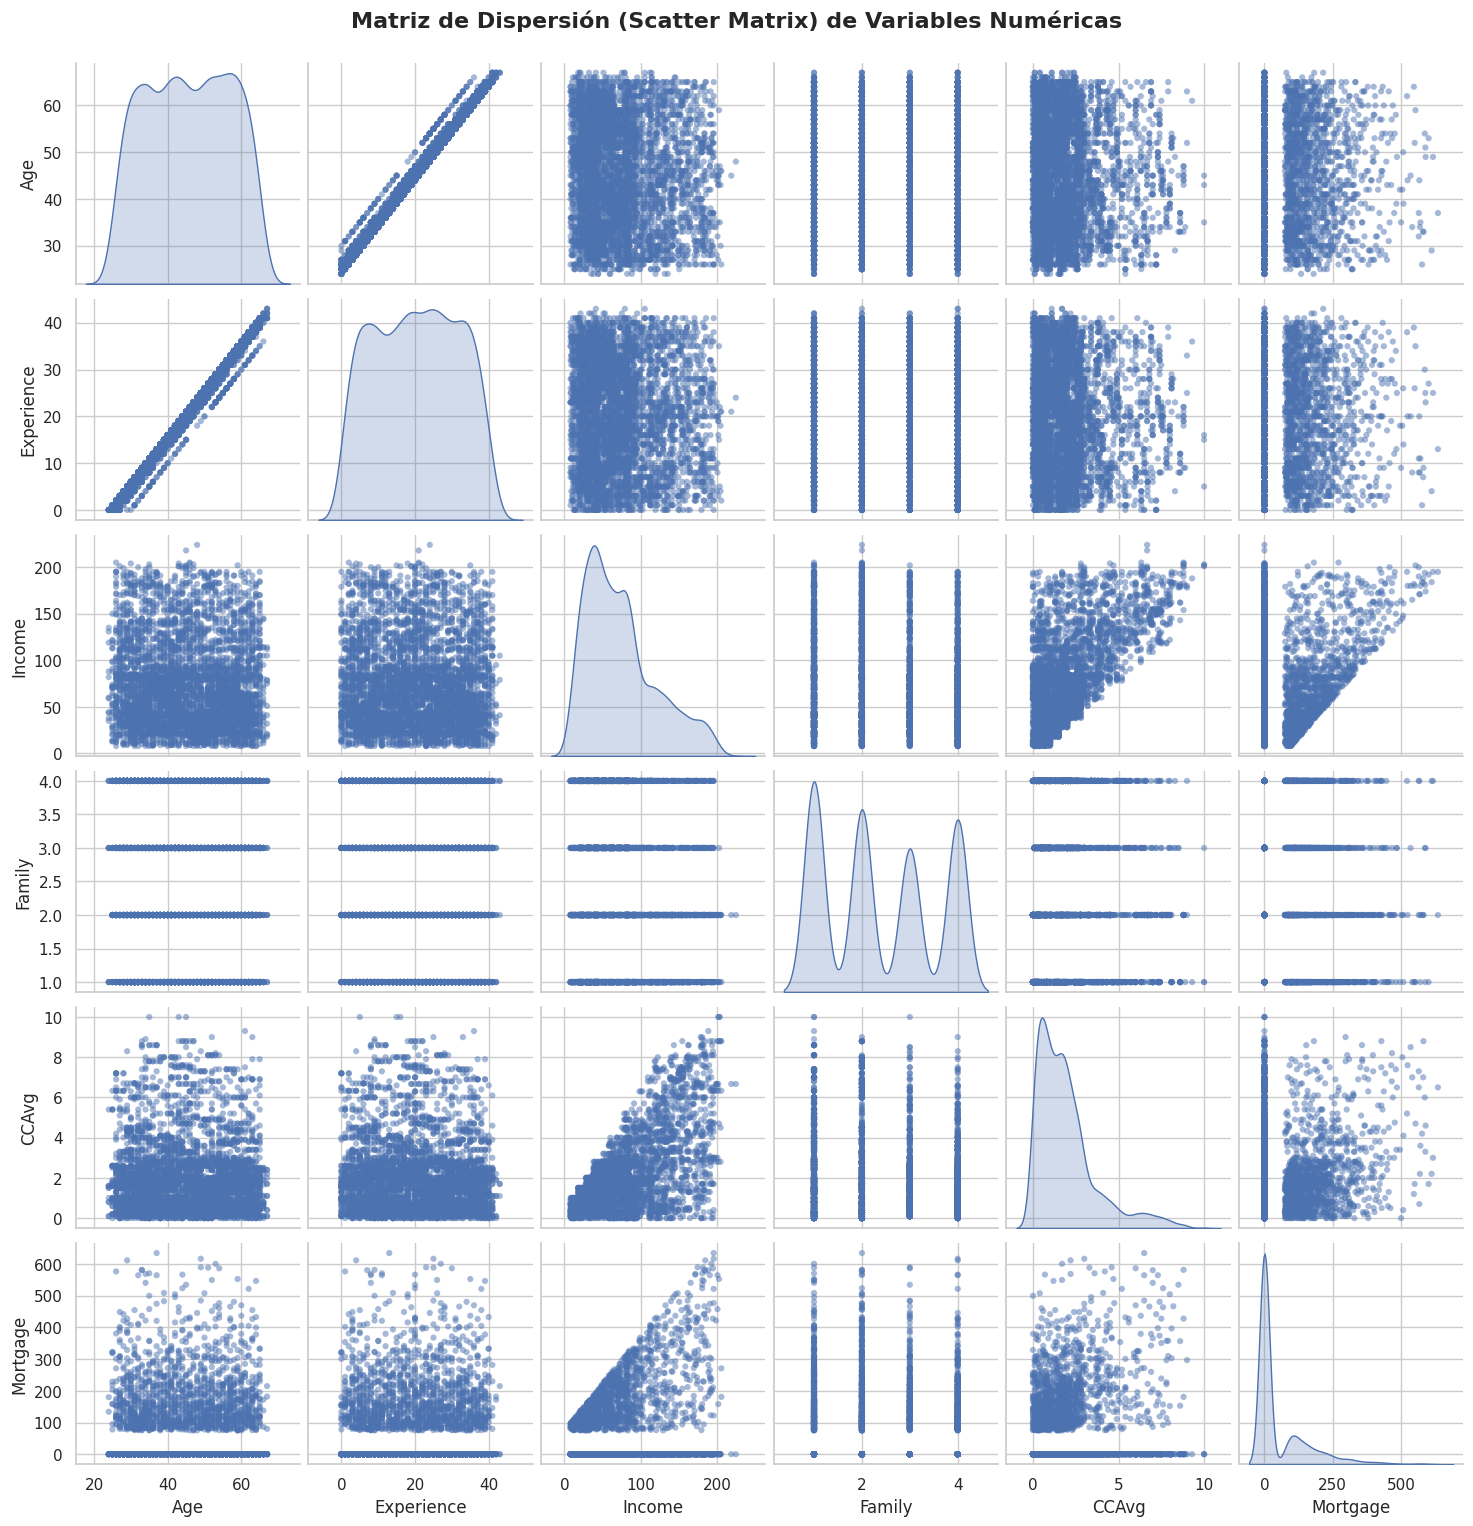

In [19]:

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

print("=== GENERANDO PAIRPLOT DE VARIABLES NUMÉRICAS ===")

# Utilizar sns.pairplot para construir la matriz de dispersión completa
# Usamos diag_kind="kde" para ver la densidad en la diagonal principal en lugar de simples histogramas
pairplot_fig = sns.pairplot(
    loan_df[num_cols],
    diag_kind="kde",
    corner=False,  # Cambia a True si solo deseas ver la mitad inferior de la matriz y evitar duplicados
    plot_kws={"alpha": 0.5, "s": 20, "edgecolor": "none"},
    diag_kws={"fill": True}
)

# Añadir un título general a la figura
pairplot_fig.fig.suptitle("Matriz de Dispersión (Scatter Matrix) de Variables Numéricas", y=1.02, fontsize=16, fontweight='bold')

plt.show()

9.1 Observa las relaciones entre las variables, selecciona un par representativo y describe los patrones o tendencias que sean evidentes.

**Las variables Age (edad) y Experience (experiencia) tienen una correlación muy alta, mientras que las variables Income (ingreso) y CCAvg/Mortgage (compras con tarjeta de crédito e hipotecas) muestran forman un patrón triangular que sugiere que a mayor ingreso mayor gasto en tarjetas de crédito y mas créditos hipotecarios.**

9.2 Para cuantificar la fuerza y dirección de las relaciones observadas, genera un mapa de calor con los valores de correlación de Pearson. ¿El valor numérico obtenido del par seleccionado se corresponde con lo esperado?

=== MATRIZ DE CORRELACIÓN DE PEARSON (MAPA DE CALOR) ===


,Age,Experience,Income,Family,CCAvg,Mortgage
Age,1.000000,0.994109,-0.058383,-0.039895,-0.050990,-0.014790
Experience,0.994109,1.000000,-0.049636,-0.046360,-0.049023,-0.013124
Income,-0.058383,-0.049636,1.000000,-0.155815,0.646029,0.207326
Family,-0.039895,-0.046360,-0.155815,1.000000,-0.107011,-0.020466
CCAvg,-0.050990,-0.049023,0.646029,-0.107011,1.000000,0.110102
Mortgage,-0.014790,-0.013124,0.207326,-0.020466,0.110102,1.000000


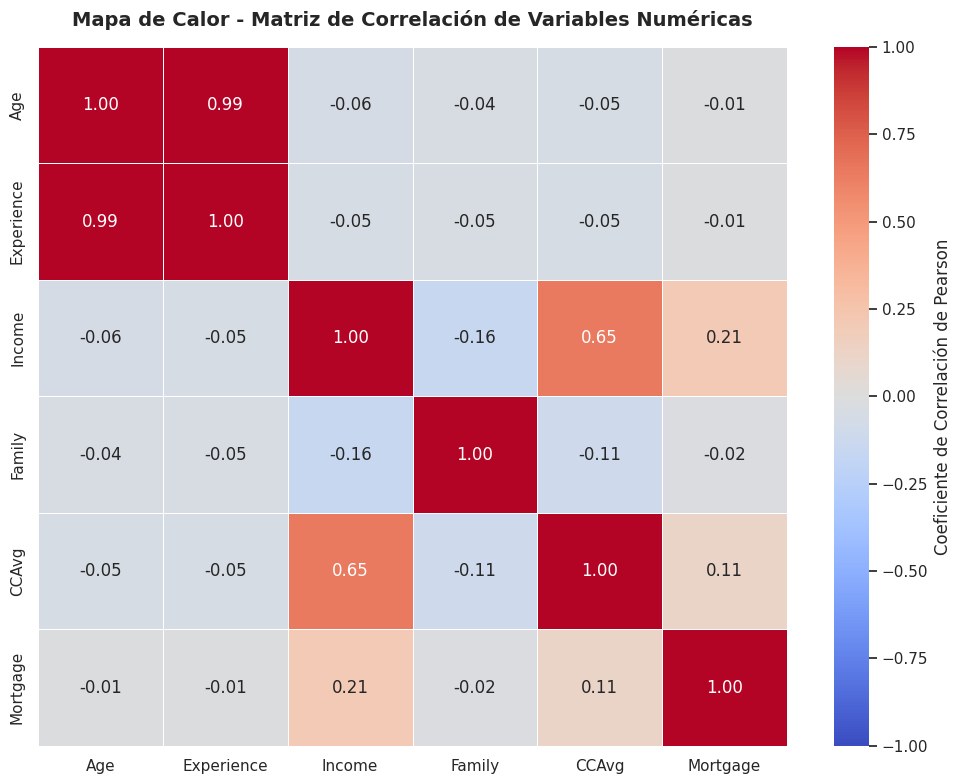

In [20]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

print("=== MATRIZ DE CORRELACIÓN DE PEARSON (MAPA DE CALOR) ===")

# Calcular la matriz de correlación utilizando el método de Pearson
# (excluimos ZIP Code ya que es nominal/identificador)
corr_matrix = loan_df[num_cols].corr(method='pearson')

# Imprimir los valores numéricos exactos en consola
display(corr_matrix)

# 2. Generar el mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # Muestra los valores numéricos dentro de las celdas
    fmt=".2f",           # Formato de dos decimales
    cmap="coolwarm",     # Paleta de colores (azul = correlación negativa, rojo = positiva)
    vmin=-1, vmax=1,     # Rango de correlación
    linewidths=0.5,
    cbar_kws={"label": "Coeficiente de Correlación de Pearson"}
)

plt.title('Mapa de Calor - Matriz de Correlación de Variables Numéricas', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Se corresponde sensiblemente**

10. Realiza un análisis de todas las variables del dataset con respecto a la variable de salida `Personal Loan`.
* Variables numéricas: Genera box plots para comparar la distribución de cada variable según los valores de `Personal Loan`.
* Variables categóricas (sin considerar `ZIP Code`): Genera gráficos de barras apiladas que muestren la distribución relativa de `Personal Loan` dentro de cada categoría de la variable.
* Para cada grupo de variables (numéricas y categóricas), comenta al menos un hallazgo o patrón relevante observado en los gráficos generados.


=== GENERANDO BOX PLOTS DE VARIABLES NUMÉRICAS VS. PERSONAL LOAN ===


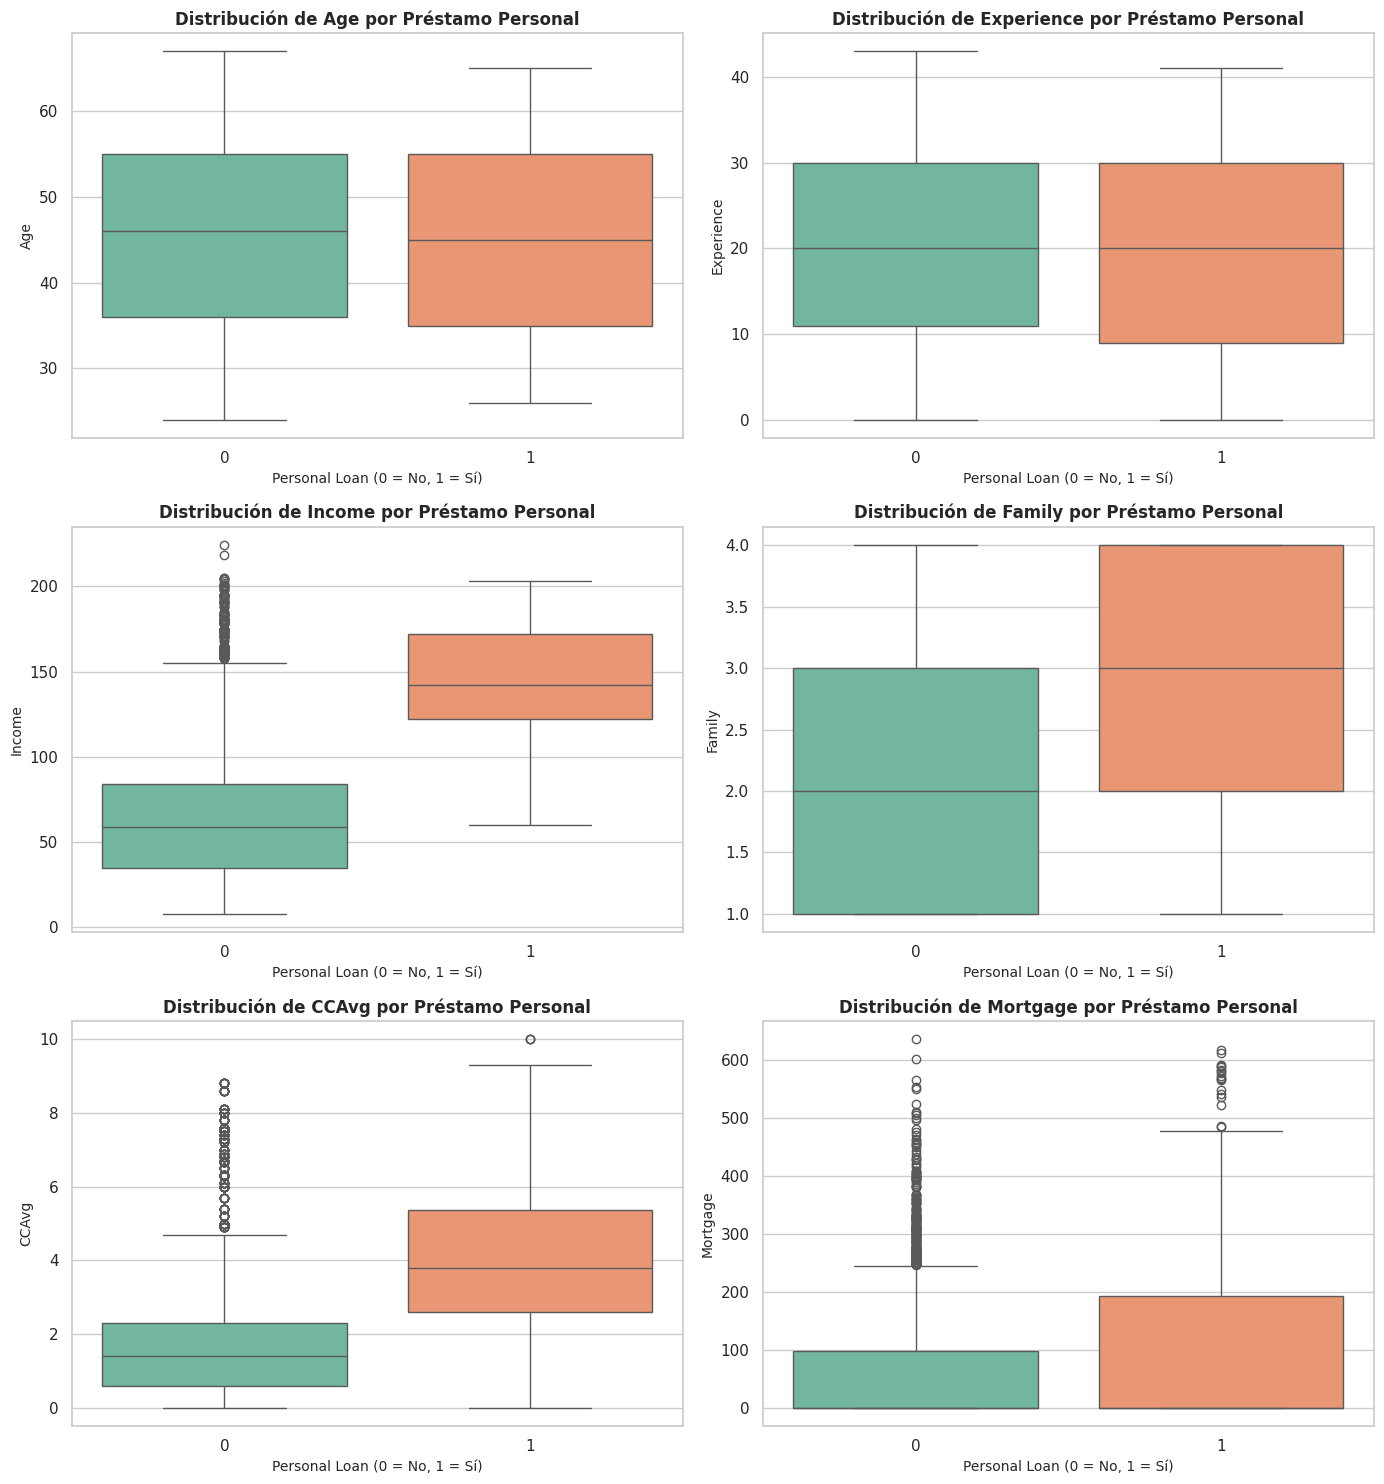

In [21]:
# Configurar el estilo visual
sns.set_theme(style="whitegrid")

print("=== GENERANDO BOX PLOTS DE VARIABLES NUMÉRICAS VS. PERSONAL LOAN ===")

# Definir la estructura de la cuadrícula (por ejemplo, 3 filas y 2 columnas para 6 variables numéricas)
num_vars = len(num_cols)
ncols_plot = 2
nrows_plot = (num_vars + ncols_plot - 1) // ncols_plot

fig, axes = plt.subplots(nrows=nrows_plot, ncols=ncols_plot, figsize=(14, 5 * nrows_plot))
axes = axes.flatten()

for i, col in enumerate(num_vars_to_plot if 'num_vars_to_plot' in locals() else num_cols):
    ax = axes[i]

    # Generar el box plot para cada variable numérica frente a Personal Loan
    sns.boxplot(
        x='Personal Loan',
        y=col,
        hue='Personal Loan',
        data=loan_df,
        ax=ax,
        palette="Set2",
        legend=False
    )

    ax.set_title(f'Distribución de {col} por Préstamo Personal', fontsize=12, fontweight='bold')
    ax.set_xlabel('Personal Loan (0 = No, 1 = Sí)', fontsize=10)
    ax.set_ylabel(col, fontsize=10)

# Ocultar subplots vacíos en caso de que sobren espacios en la cuadrícula
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

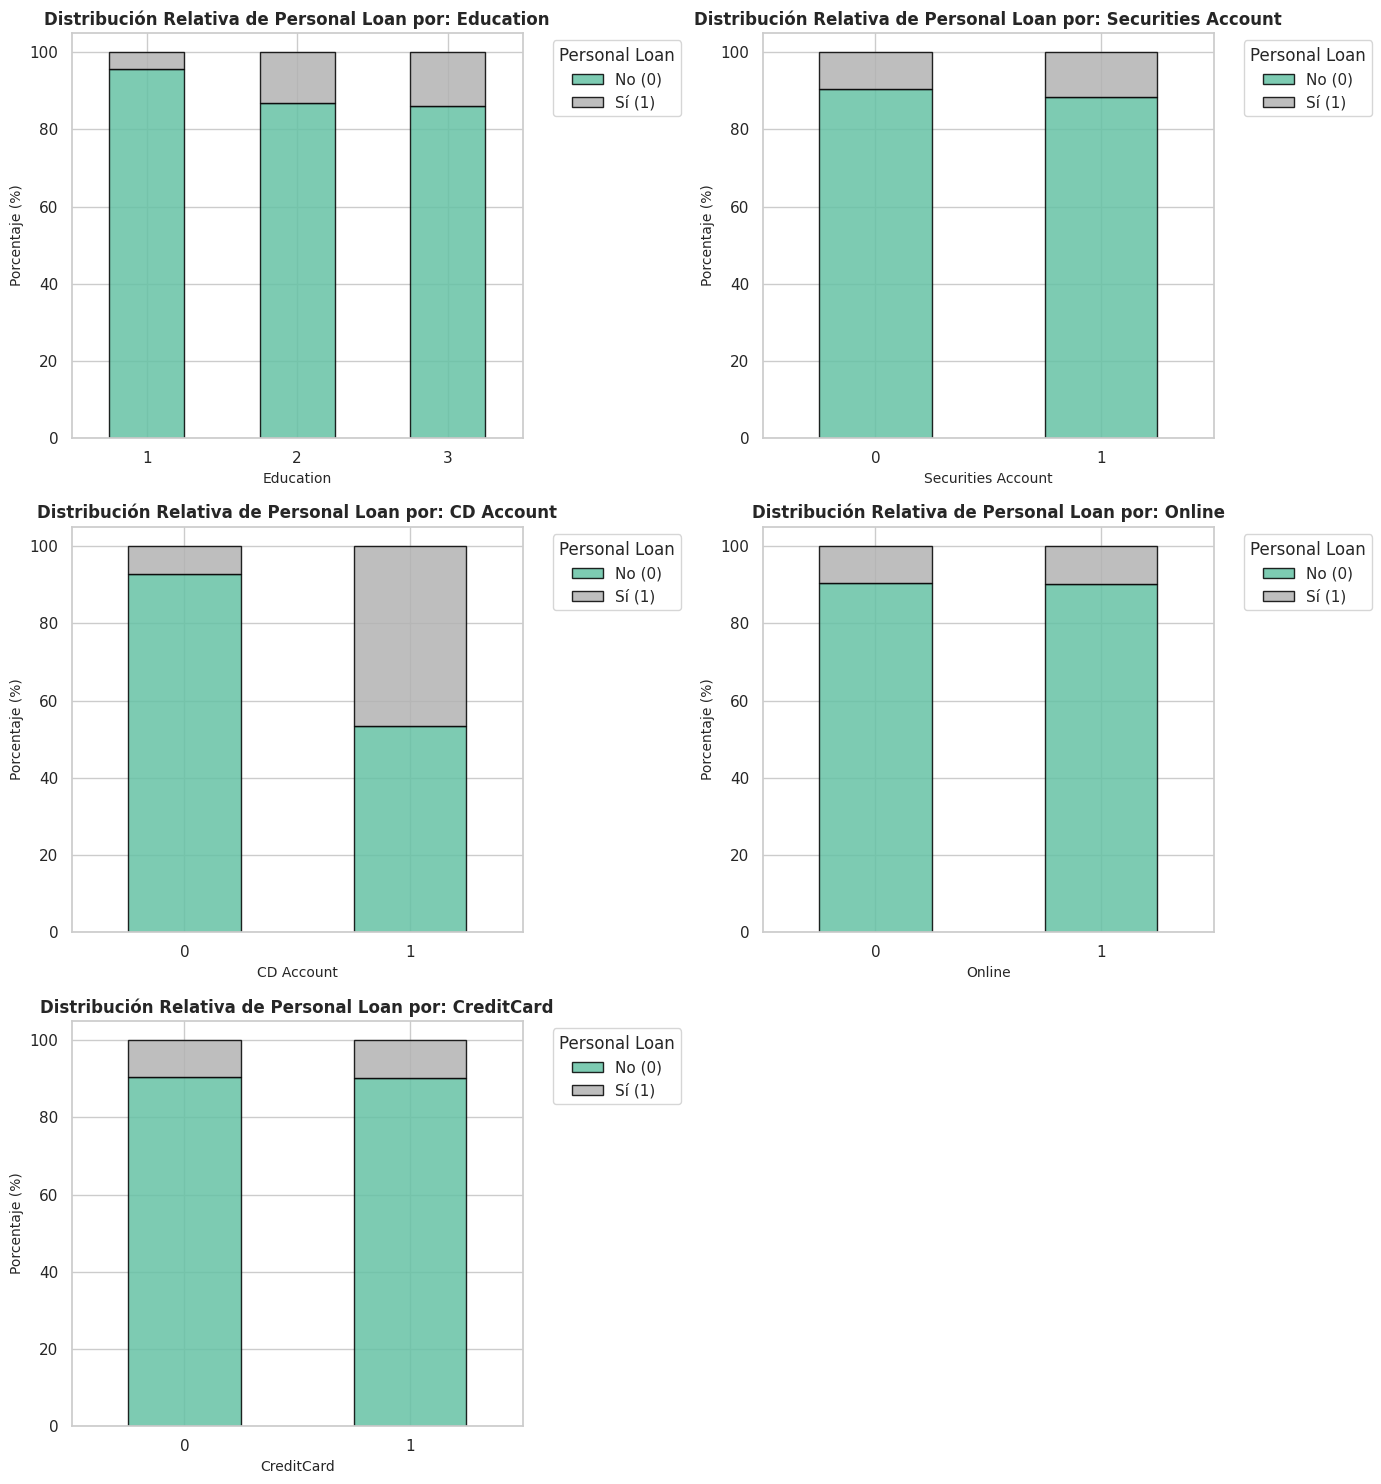

In [22]:
# Configurar estilo
sns.set_theme(style="whitegrid")

# Excluir ZIP Code y asegurarnos de usar solo las categóricas reales (incluyendo Education)
cats_para_barras = [col for col in cat_cols if col != 'Personal Loan']

num_vars = len(cats_para_barras)
ncols_plot = 2
nrows_plot = (num_vars + ncols_plot - 1) // ncols_plot

fig, axes = plt.subplots(nrows=nrows_plot, ncols=ncols_plot, figsize=(14, 5 * nrows_plot))
axes = axes.flatten()

for i, col in enumerate(cats_para_barras):
    ax = axes[i]

    # Crear una tabla de contingencia normalizada por filas (proporciones del 100%) sin el parámetro observed
    tabla_prop = pd.crosstab(loan_df[col], loan_df['Personal Loan'], normalize='index') * 100

    # Generar el gráfico de barras apiladas
    tabla_prop.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        colormap='Set2',
        edgecolor='black',
        alpha=0.85
    )

    ax.set_title(f'Distribución Relativa de Personal Loan por: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Porcentaje (%)', fontsize=10)
    ax.legend(title='Personal Loan', labels=['No (0)', 'Sí (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=0)

# Ocultar subplots vacíos si sobran espacios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Hallazgos para variables numéricas vs. Personal Loan.**

Si bien mayores ingresos se correlacionan con los préstamos personales, existen muchos datos de personas con altos ingresos que no solicitan préstamos personales.
Existen rangos de edad claramente diferenciados con mayor probabilidad de tener éxito en colocar un préstamo personal, pero tener altos ingresos no es garantía de éxito.

En cuanto al gasto en tarjeta de crédito (CCAvg) hay también una mayor concentración de préstamos personales cuanto mayor es el monto de gasto promedio, aunque también hay outliers entre quienes tienen un gasto promedio alto.

En general las familias de dos a cuatro integrantes solicitan más préstamos personales que los que tienen de tres o menos.

Es más frecuente que soliciten un préstamo personas quienes tienen una hipoteca, incluyendo muchos valores altos de hipoteca (outliers), lo que indicaría que personas con deudas hipotecarias fuertes también acceden a los préstamos personales.


**Hallazgos en las variables categóricas vs. Personal Loan**

Sólo me resultan determinantes el grado de educación, pues los préstamos personales se concentran entre los grados 2 y 3 y entre quienes tienen una cuenta de certificado de depósito (cuentas de inversión a plazo fijo). Esté último punto podría explicar la tasa de aceptación de una solicitud por quien otorga el préstamo personal, tal como debe ocurrir con el gasto promedio en tarjetas de crédito, pues forman parte del historial de crédito de una persona.


**Declaración de uso de IA**

Google. (2026). Gemini (Modelo de lenguaje grande), utilizado para generación y depuración de código. https://gemini.google.com/

---

**Declaración de uso de IA**

Si aplica, deberá indicarse la herramienta y el modelo empleado en la entrega, así como la finalidad de su uso (generación de código / depuración / optimización).

Por ejemplo:

*   OpenAI. (2026). *ChatGPT (basado en GPT-4)* [Modelo de lenguaje grande], utilizado para generación de código y depuración. https://chat.openai.com/

---